# Predictive Risk Modeling for Global Freight Delays
### Using Multi-Modal Operational Streams — Classification Approach

**Data Source:** Supply Chain and Freight Indicators — U.S. DOT / MARAD ([data.gov](https://catalog.data.gov/dataset/supply-chain-and-freight-indicators))

**Notebook type:** End-to-end analysis — EDA, feature engineering, anomaly detection, binary
delay-risk classification modeling (classic ML and deep learning), explainability, evaluation,
and a full dissertation-ready dashboard suite.

---

**Aim:** Build a predictive risk-classification framework that identifies, measures, and predicts
freight-delay risk across global supply chains using real-time, multi-modal operational data
(containership capacity, port call frequency/volume, rail and truck performance).

**Research Question:** Can multi-modal port and freight operational data be used to accurately
classify short-term freight-delay risk as high-risk vs. low-risk, and which classification
approach performs best?

**Research Objectives**
1. Evaluate freight and supply-chain indicators (2019–present) to identify delay signals / anomalies.
2. Build predictive classification models estimating high-risk vs. low-risk disruption at U.S. ports.
3. Compare classifier effectiveness (classic ML and deep learning) across pre-, during-, and post-COVID regimes.
4. Produce an interpretable 0–100 risk-scoring index for logistics decision-makers.

**Note on scope (per supervisor feedback):** This notebook focuses exclusively on the
**classification** formulation of the problem — predicting whether next-week freight risk will
exceed the 75th-percentile threshold (high-risk = 1 / low-risk = 0). Earlier drafts mixed
regression (continuous-value forecasting) and classification models, which made the modeling
narrative and metrics hard to follow. All regression-only models (SARIMA, Linear Regression,
and the regression heads of Random Forest / XGBoost / LSTM / Transformer) have been removed so
that every model, hyperparameter, and metric reported below refers to the same binary
delay-risk classification target.

## Contents
1. Environment Setup
2. Data Loading
3. Data Cleaning & Preprocessing
4. Composite Freight Risk / Congestion Index
5. Exploratory Data Analysis (10 dashboards)
6. Feature Engineering
7. Anomaly Detection (Isolation Forest + CUSUM)
8. Train / Test Split (Chronological)
9. Baseline Classification Models — Logistic Regression, Random Forest
10. Advanced Classification Models — LSTM, Transformer, XGBoost + SHAP
11. Model Evaluation & Comparison (Classification)
12. Freight Risk Score Timeline

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              mean_absolute_percentage_error, roc_auc_score,
                              f1_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping
import xgboost as xgb
import shap
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': '#333333',
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.titlesize': 15, 'figure.titleweight': 'bold', 'grid.alpha': 0.3,
    'font.family': 'sans-serif'
})
COLOR_MAIN, COLOR_ACCENT, COLOR_OK, COLOR_WARN = '#1f4e79', '#c0392b', '#2e8b57', '#e08214'
COVID_START, COVID_END = pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31")
STRIKE_START, STRIKE_END = pd.Timestamp("2023-06-01"), pd.Timestamp("2023-07-31")
print("Environment ready — TensorFlow:", tf.__version__)

Environment ready — TensorFlow: 2.20.0


## 2. Data Loading
Upload `Supply_Chain_and_Freight_Indicators.csv` when prompted (Google Colab file picker).
If running locally / outside Colab, place the file alongside the notebook and the upload step
will be skipped automatically.

In [2]:
try:
    from google.colab import files
    print("Please upload 'Supply_Chain_and_Freight_Indicators.csv'")
    uploaded = files.upload()
    FILE_NAME = list(uploaded.keys())[0]
except ImportError:
    FILE_NAME = "Supply_Chain_and_Freight_Indicators.csv"
df_raw = pd.read_csv(FILE_NAME)

Please upload 'Supply_Chain_and_Freight_Indicators.csv'


Saving Supply_Chain_and_Freight_Indicators.csv to Supply_Chain_and_Freight_Indicators.csv


In [3]:
print("Shape:", df_raw.shape)

Shape: (26135, 12)


In [4]:
df_raw.head()

,ID,DATE,YEAR,INDICATOR,MEASURE1,MEASURE2,MEASURE1_DESCRIPTION,MEASURE2_DESCRIPTION,VALUE1,UNITS,NOTE,SOURCE
0,1_2019_01_06,2019 Jan 06 12:00:00 AM,"2,019",Capacity of Containerships Calling at U.S. Por...,NaN,NaN,NaN,NaN,"1,692,044",TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...
1,1_2019_01_13,2019 Jan 13 12:00:00 AM,"2,019",Capacity of Containerships Calling at U.S. Por...,NaN,NaN,NaN,NaN,"2,032,538",TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...
2,1_2019_01_20,2019 Jan 20 12:00:00 AM,"2,019",Capacity of Containerships Calling at U.S. Por...,NaN,NaN,NaN,NaN,"2,037,507",TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...
3,1_2019_01_27,2019 Jan 27 12:00:00 AM,"2,019",Capacity of Containerships Calling at U.S. Por...,NaN,NaN,NaN,NaN,"2,032,424",TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...
4,1_2019_02_03,2019 Feb 03 12:00:00 AM,"2,019",Capacity of Containerships Calling at U.S. Por...,NaN,NaN,NaN,NaN,"2,055,851",TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26135 entries, 0 to 26134
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    26135 non-null  object
 1   DATE                  25904 non-null  object
 2   YEAR                  26135 non-null  object
 3   INDICATOR             26135 non-null  object
 4   MEASURE1              22059 non-null  object
 5   MEASURE2              6129 non-null   object
 6   MEASURE1_DESCRIPTION  22059 non-null  object
 7   MEASURE2_DESCRIPTION  6129 non-null   object
 8   VALUE1                25853 non-null  object
 9   UNITS                 26135 non-null  object
 10  NOTE                  13746 non-null  object
 11  SOURCE                26135 non-null  object
dtypes: object(12)
memory usage: 2.4+ MB


In [6]:
print("\nColumns:", list(df_raw.columns))


Columns: ['ID', 'DATE', 'YEAR', 'INDICATOR', 'MEASURE1', 'MEASURE2', 'MEASURE1_DESCRIPTION', 'MEASURE2_DESCRIPTION', 'VALUE1', 'UNITS', 'NOTE', 'SOURCE']


In [7]:
print("\nUnique indicators in the dataset:")


Unique indicators in the dataset:


In [8]:
print(df_raw['INDICATOR'].value_counts())

INDICATOR
Average Dwell Time at Class I Railroad Terminals                                                                                5898
Downbound Grain Barge Rates                                                                                                     2772
Average Terminal Dwell Time in Hours by Railroad                                                                                1973
Average Train Speed in MPH by Railroad                                                                                          1973
Rail Cars Online                                                                                                                1973
Number of Containerships Awaiting Berths at all U.S. Ports                                                                      1176
Truck Spot Rates in $ per Mile by Truck Type                                                                                    1155
Empty Export Containers at Select U.S. Ports in TEUs       

## 3. Data Cleaning & Preprocessing

In [9]:
df = df_raw.copy()
def clean_numeric(series):
    return (series.astype(str)
                  .str.replace(',', '', regex=False)
                  .str.replace(r'[^\d\.\-]', '', regex=True)
                  .replace('', np.nan)
                  .astype(float))
df['VALUE1'] = clean_numeric(df['VALUE1'])
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['YEAR'] = pd.to_numeric(df['YEAR'].astype(str).str.replace(',', '', regex=False), errors='coerce')
for col in ['MEASURE1', 'MEASURE2', 'MEASURE1_DESCRIPTION', 'MEASURE2_DESCRIPTION']:
    if col in df.columns and df[col].isna().all():
        df.drop(columns=col, inplace=True)
df = df.dropna(subset=['DATE', 'VALUE1']).sort_values('DATE').reset_index(drop=True)

In [10]:
print("Cleaned shape:", df.shape)
print("Date range:", df['DATE'].min().date(), "to", df['DATE'].max().date())

Cleaned shape: (25632, 12)
Date range: 2017-01-01 to 2026-08-03


In [11]:
df.head()

,ID,DATE,YEAR,INDICATOR,MEASURE1,MEASURE2,MEASURE1_DESCRIPTION,MEASURE2_DESCRIPTION,VALUE1,UNITS,NOTE,SOURCE
0,46_2017_01_01_Total New Active Carriers Added ...,2017-01-01,2017,New Active Carriers Added to MCMIS: Total New ...,Total New Active Carriers Added to MCMIS,NaN,"Total, for-hire, or private new active carriers",NaN,4987.000,Number of new active carriers,For-hire carriers includes either for-hire onl...,Federal Motor Carrier Safety Administration's ...
1,46_2017_01_01_New Active Private Carriers Adde...,2017-01-01,2017,New Active Carriers Added to MCMIS: Total New ...,New Active Private Carriers Added to MCMIS,NaN,"Total, for-hire, or private new active carriers",NaN,1879.000,Number of new active carriers,For-hire carriers includes either for-hire onl...,Federal Motor Carrier Safety Administration's ...
2,38_2017_01_01_Dry Van,2017-01-01,2017,Truck Spot Rates in $ per Mile by Truck Type,Dry Van,NaN,Dry van; refrigerated; or flatbeds,NaN,1.473,Dollars per mile,"This data is for spot market trucking loads, w...",DAT Freight and Analytics
3,38_2017_01_01_Flatbeds,2017-01-01,2017,Truck Spot Rates in $ per Mile by Truck Type,Flatbeds,NaN,Dry van; refrigerated; or flatbeds,NaN,1.616,Dollars per mile,"This data is for spot market trucking loads, w...",DAT Freight and Analytics
4,38_2017_01_01_Refrigerated,2017-01-01,2017,Truck Spot Rates in $ per Mile by Truck Type,Refrigerated,NaN,Dry van; refrigerated; or flatbeds,NaN,1.747,Dollars per mile,"This data is for spot market trucking loads, w...",DAT Freight and Analytics


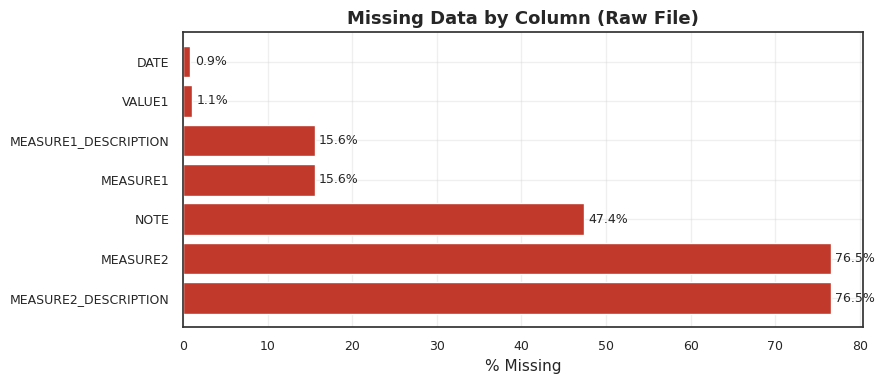

In [12]:
missing = df_raw.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(9, 4))
if len(missing) > 0:
    ax.barh(missing.index, missing.values, color=COLOR_ACCENT)
    ax.set_xlabel('% Missing'); ax.set_title('Missing Data by Column (Raw File)')
    for i, v in enumerate(missing.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values detected", ha='center', va='center', fontsize=12)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [13]:
counts = df["INDICATOR"].value_counts()
PREFERRED_KEYWORDS = [
    "Containerships Calling", "Awaiting Berths", "Anchored",
    "Containerized Imports", "Containerized Exports",
    "Loaded Import Containers", "Loaded Export Containers", "Empty Export Containers",
    "Planning Time Index", "PTI", "Bottleneck",
    "Train Speed", "Terminal Dwell Time", "Dwell Time", "Rail Cars",
    "Rail Intermodal", "Rail Flat Cars", "Rail Carloads", "Rail Transportation",
    "Truck Speed", "Truck Spot Rates", "Truck Transportation",
    "Freight Rates", "Freight Transportation", "Diesel", "Producer Price Index",
    "Inventory", "Goods Imports", "Warehousing", "Job Openings",
    "Grain Barge", "Vehicle Miles", "New Active Carriers"
]
matched = [ind for ind in counts.index if any(kw.lower() in ind.lower() for kw in PREFERRED_KEYWORDS)]
TOP_N = 10
selected_indicators = matched[:TOP_N]
if len(selected_indicators) < TOP_N:
    backfill = [i for i in counts.index if i not in selected_indicators]
    selected_indicators += backfill[: TOP_N - len(selected_indicators)]
print("Selected indicators for the multi-modal panel:")
for i, ind in enumerate(selected_indicators, 1):
    print(f"  {i:2d}. {ind}  (n={counts[ind]})")

Selected indicators for the multi-modal panel:
   1. Average Dwell Time at Class I Railroad Terminals  (n=5898)
   2. Downbound Grain Barge Rates  (n=2500)
   3. Rail Cars Online  (n=1973)
   4. Average Train Speed in MPH by Railroad  (n=1973)
   5. Average Terminal Dwell Time in Hours by Railroad  (n=1973)
   6. Number of Containerships Awaiting Berths at all U.S. Ports  (n=1176)
   7. Truck Spot Rates in $ per Mile by Truck Type  (n=1155)
   8. Loaded Export Containers at Select U.S. Ports in TEUs  (n=801)
   9. Empty Export Containers at Select U.S. Ports in TEUs  (n=801)
  10. Loaded Import Containers at Select U.S. Ports in TEUs  (n=801)


In [14]:
panel_long = df[df["INDICATOR"].isin(selected_indicators)].copy()
wide = panel_long.pivot_table(index="DATE", columns="INDICATOR", values="VALUE1", aggfunc="mean")
wide = wide.resample("W").mean()
wide = wide.interpolate(method="linear", limit=4, limit_direction="both")
wide = wide.ffill().bfill()
short_names = {c: (c if len(c) <= 40 else c[:37] + "...") for c in wide.columns}
wide = wide.rename(columns=short_names)
print("Weekly panel shape:", wide.shape)
wide.head()

Weekly panel shape: (501, 10)


INDICATOR,Average Dwell Time at Class I Railroa...,Average Terminal Dwell Time in Hours ...,Average Train Speed in MPH by Railroad,Downbound Grain Barge Rates,Empty Export Containers at Select U.S...,Loaded Export Containers at Select U....,Loaded Import Containers at Select U....,Number of Containerships Awaiting Ber...,Rail Cars Online,Truck Spot Rates in $ per Mile by Tru...
DATE,,,,,,,,,,
2017-01-01,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.612000
2017-01-08,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.616000
2017-01-15,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.604667
2017-01-22,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.586333
2017-01-29,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.590000


## 4. Composite Freight Risk / Congestion Index


In [15]:
scaler_ci = StandardScaler()
z_wide = pd.DataFrame(scaler_ci.fit_transform(wide), index=wide.index, columns=wide.columns)
congestion_index = z_wide.mean(axis=1)
freight_risk_score = ((congestion_index - congestion_index.min()) /
                       (congestion_index.max() - congestion_index.min())) * 100
wide_ci = wide.copy()
wide_ci["congestion_index"] = congestion_index
wide_ci["freight_risk_score"] = freight_risk_score
PRIMARY_KEYWORDS = ["Awaiting Berths", "Anchored", "Dwell Time", "Calling"]
primary_candidates = [c for c in wide.columns if any(k.lower() in c.lower() for k in PRIMARY_KEYWORDS)]
PRIMARY_COL = primary_candidates[0] if primary_candidates else wide.columns[0]
print("Primary target series:", PRIMARY_COL)
wide_ci[["congestion_index", "freight_risk_score"]].describe()

Primary target series: Average Dwell Time at Class I Railroa...


INDICATOR,congestion_index,freight_risk_score
count,5.010000e+02,501.000000
mean,5.274113e-16,45.708471
std,3.026440e-01,18.831308
min,-7.345955e-01,0.000000
25%,-2.110110e-01,32.578807
50%,1.917609e-02,46.901658
75%,1.675093e-01,56.131344
max,8.725365e-01,100.000000


## 5. Exploratory Data Analysis

### 5.1 Dashboard — Multi-Modal Freight Indicator Overview (3×3 grid)

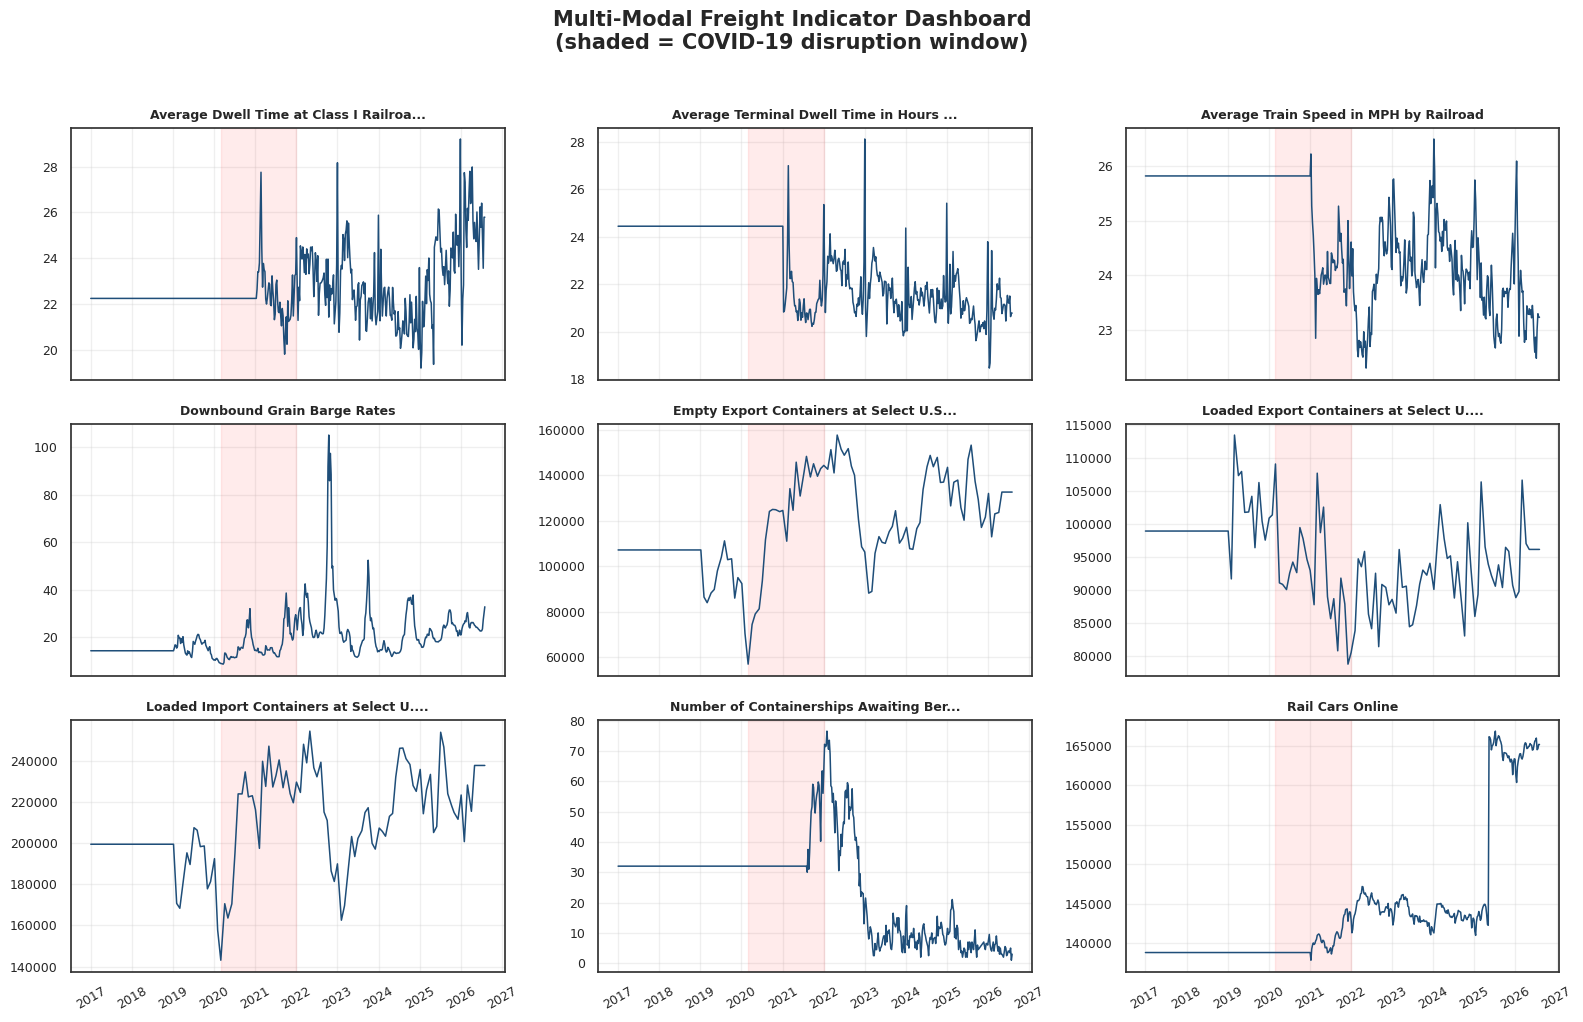

In [16]:
plot_cols = list(wide.columns[:9])
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    ax.plot(wide.index, wide[col], color=COLOR_MAIN, linewidth=1.1)
    ax.axvspan(COVID_START, COVID_END, color="red", alpha=0.08)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', rotation=30)
for ax in axes[len(plot_cols):]:
    ax.axis('off')
fig.suptitle("Multi-Modal Freight Indicator Dashboard\n(shaded = COVID-19 disruption window)", y=1.02)
plt.tight_layout(); plt.show()

### 5.2 Dashboard — Indicator Availability & Coverage

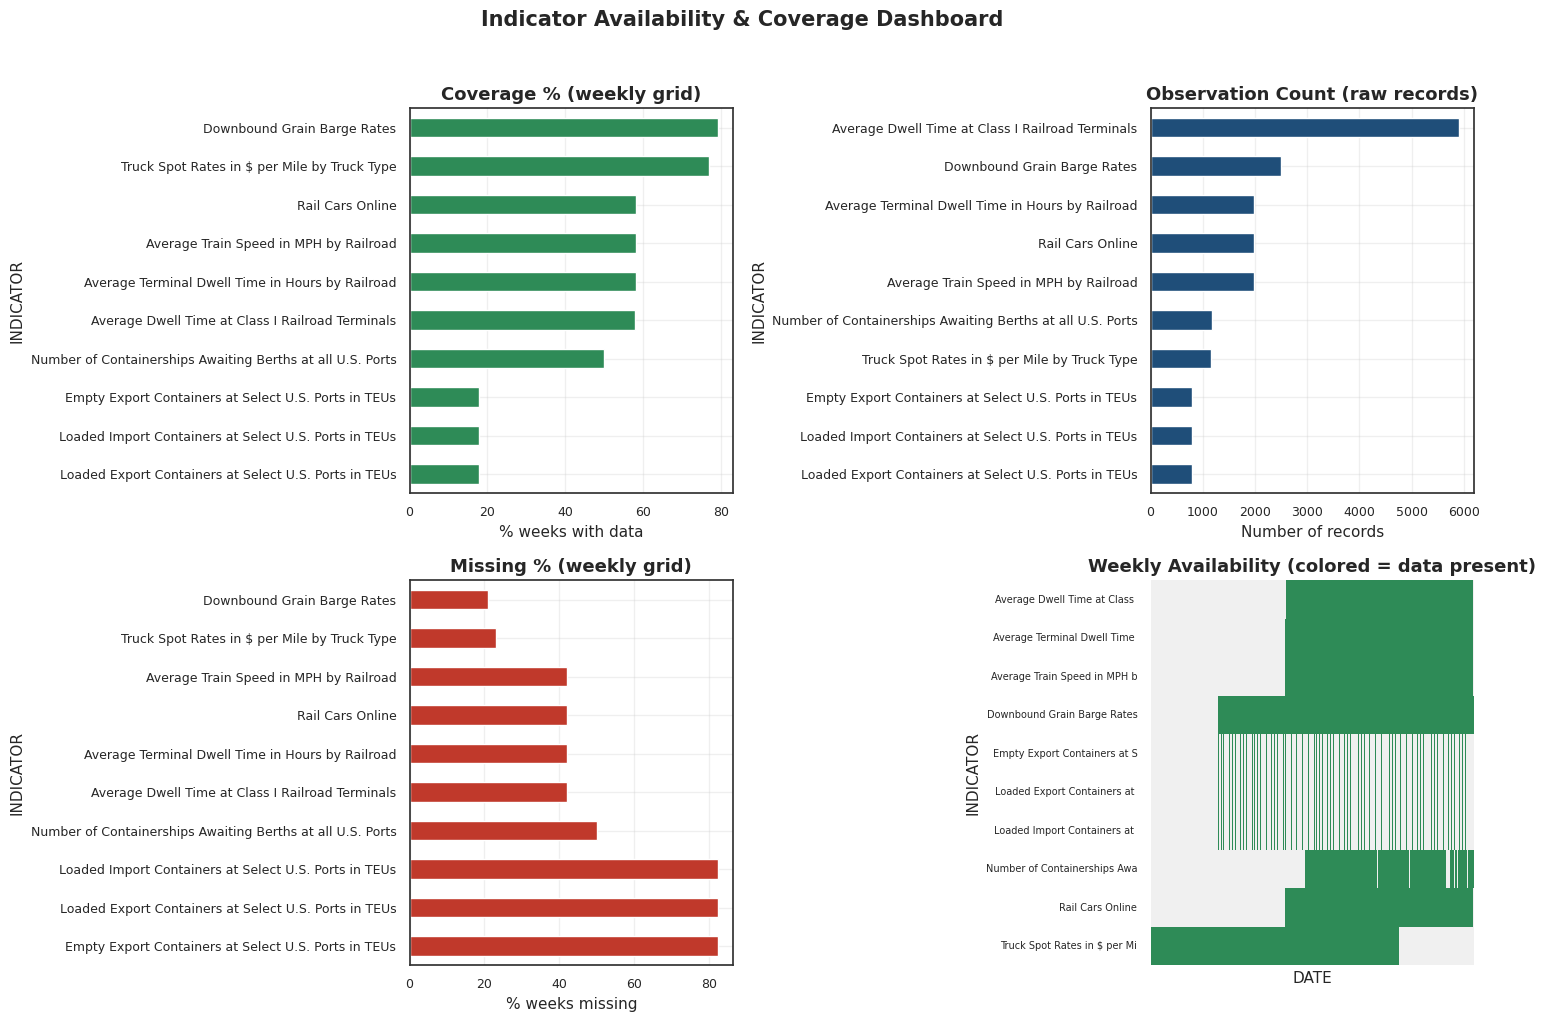

In [17]:
raw_grid = panel_long.pivot_table(index="DATE", columns="INDICATOR", values="VALUE1", aggfunc="mean")
raw_grid_w = raw_grid.resample("W").mean()
coverage_pct = (1 - raw_grid_w.isna().mean()) * 100
missing_pct = 100 - coverage_pct
obs_count = counts.reindex(coverage_pct.index)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
coverage_pct.sort_values().plot(kind='barh', ax=axes[0, 0], color=COLOR_OK)
axes[0, 0].set_title("Coverage % (weekly grid)"); axes[0, 0].set_xlabel("% weeks with data")
obs_count.sort_values().plot(kind='barh', ax=axes[0, 1], color=COLOR_MAIN)
axes[0, 1].set_title("Observation Count (raw records)"); axes[0, 1].set_xlabel("Number of records")
missing_pct.sort_values(ascending=False).plot(kind='barh', ax=axes[1, 0], color=COLOR_ACCENT)
axes[1, 0].set_title("Missing % (weekly grid)"); axes[1, 0].set_xlabel("% weeks missing")
availability = (~raw_grid_w.isna()).astype(int).T
sns.heatmap(availability, ax=axes[1, 1], cmap=["#f0f0f0", COLOR_OK], cbar=False)
axes[1, 1].set_title("Weekly Availability (colored = data present)")
axes[1, 1].set_yticklabels([t.get_text()[:28] for t in axes[1, 1].get_yticklabels()], fontsize=7)
axes[1, 1].set_xticks([])
fig.suptitle("Indicator Availability & Coverage Dashboard", y=1.02)
plt.tight_layout(); plt.show()

### 5.3 Dashboard — Monthly Seasonal Heatmap

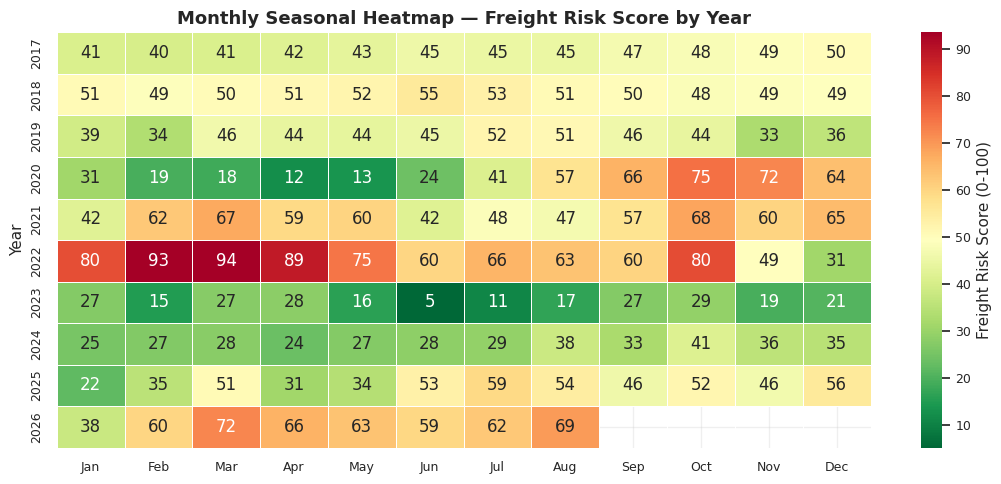

In [18]:
seasonal_tbl = wide_ci[["freight_risk_score"]].copy()
seasonal_tbl["Year"] = seasonal_tbl.index.year
seasonal_tbl["Month"] = seasonal_tbl.index.month
pivot_season = seasonal_tbl.pivot_table(index="Year", columns="Month", values="freight_risk_score", aggfunc="mean")
pivot_season.columns = [pd.Timestamp(2000, m, 1).strftime('%b') for m in pivot_season.columns]
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot_season, cmap="RdYlGn_r", annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={'label': 'Freight Risk Score (0-100)'}, ax=ax)
ax.set_title("Monthly Seasonal Heatmap — Freight Risk Score by Year")
plt.tight_layout(); plt.show()


### 5.4 Dashboard — Year-over-Year Trend Comparison

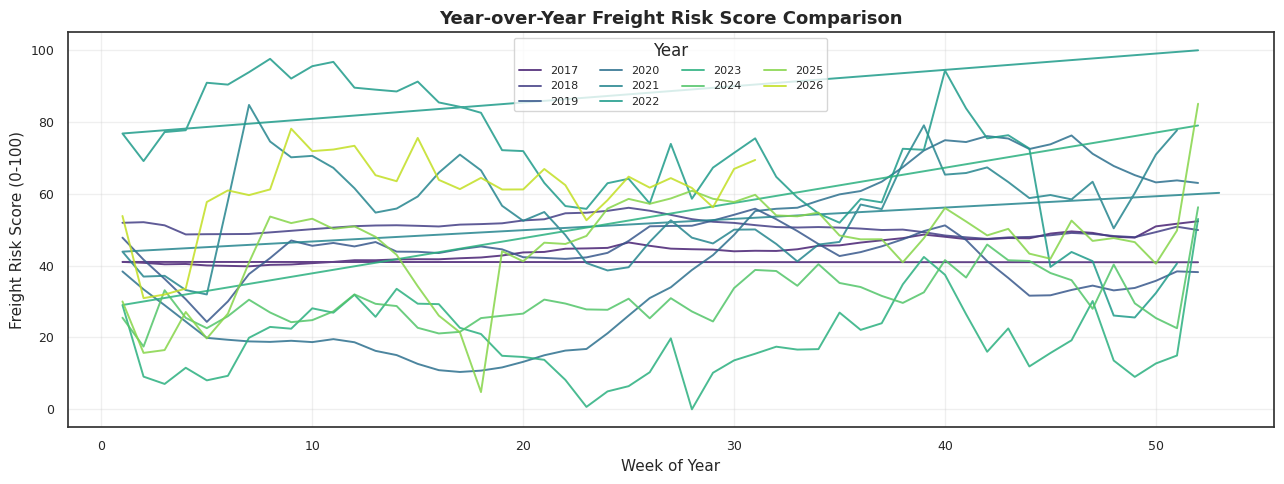

In [19]:
yoy = wide_ci[["freight_risk_score"]].copy()
yoy["Year"] = yoy.index.year
yoy["Week"] = yoy.index.isocalendar().week.astype(int)
fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette("viridis", n_colors=yoy["Year"].nunique())
for color, (yr, grp) in zip(palette, yoy.groupby("Year")):
    ax.plot(grp["Week"], grp["freight_risk_score"], label=str(yr), color=color, linewidth=1.4, alpha=0.85)
ax.set_xlabel("Week of Year"); ax.set_ylabel("Freight Risk Score (0-100)")
ax.set_title("Year-over-Year Freight Risk Score Comparison")
ax.legend(title="Year", ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

### 5.5 Dashboard — Correlation Heatmap (Selected Indicators)

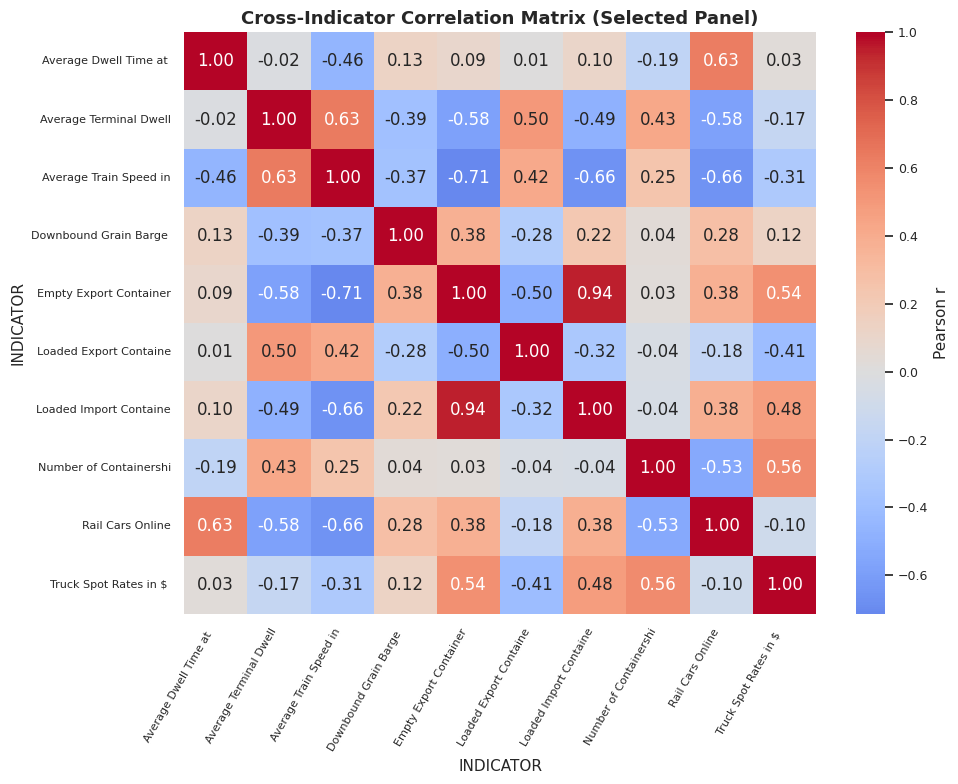

In [20]:
corr = wide.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=len(corr) <= 12, fmt=".2f",
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Cross-Indicator Correlation Matrix (Selected Panel)")
ax.set_xticklabels([t.get_text()[:22] for t in ax.get_xticklabels()], rotation=60, ha='right', fontsize=8)
ax.set_yticklabels([t.get_text()[:22] for t in ax.get_yticklabels()], fontsize=8)
plt.tight_layout(); plt.show()

### 5.6 Primary Series Deep-Dive — Distribution & Rolling Statistics

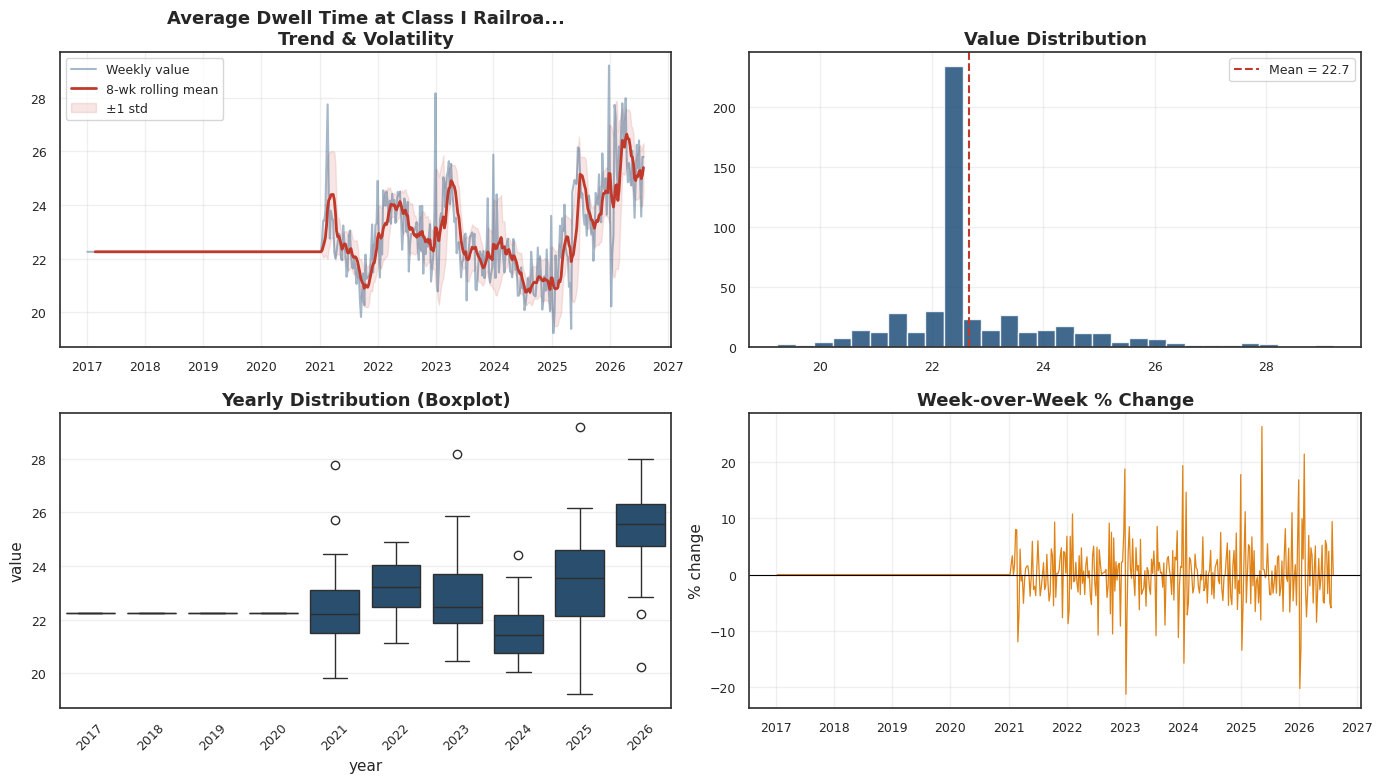

In [21]:
series = wide[PRIMARY_COL].interpolate()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
roll_mean, roll_std = series.rolling(8).mean(), series.rolling(8).std()
axes[0, 0].plot(series.index, series, color=COLOR_MAIN, alpha=0.4, label='Weekly value')
axes[0, 0].plot(roll_mean.index, roll_mean, color=COLOR_ACCENT, linewidth=2, label='8-wk rolling mean')
axes[0, 0].fill_between(series.index, roll_mean - roll_std, roll_mean + roll_std, color=COLOR_ACCENT, alpha=0.12, label='±1 std')
axes[0, 0].set_title(f'{PRIMARY_COL}\nTrend & Volatility'); axes[0, 0].legend()
axes[0, 1].hist(series.dropna(), bins=30, color=COLOR_MAIN, edgecolor='white', alpha=0.85)
axes[0, 1].axvline(series.mean(), color=COLOR_ACCENT, linestyle='--', label=f'Mean = {series.mean():,.1f}')
axes[0, 1].set_title('Value Distribution'); axes[0, 1].legend()
tmp = series.to_frame('value').reset_index(); tmp['year'] = tmp['DATE'].dt.year
sns.boxplot(data=tmp, x='year', y='value', ax=axes[1, 0], color=COLOR_MAIN)
axes[1, 0].set_title('Yearly Distribution (Boxplot)')
axes[1, 0].tick_params(axis='x', rotation=45)
pct_change = series.pct_change() * 100
axes[1, 1].plot(pct_change.index, pct_change, color=COLOR_WARN, linewidth=0.9)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Week-over-Week % Change'); axes[1, 1].set_ylabel('% change')
plt.tight_layout(); plt.show()

### 5.7 Seasonal Decomposition & Stationarity

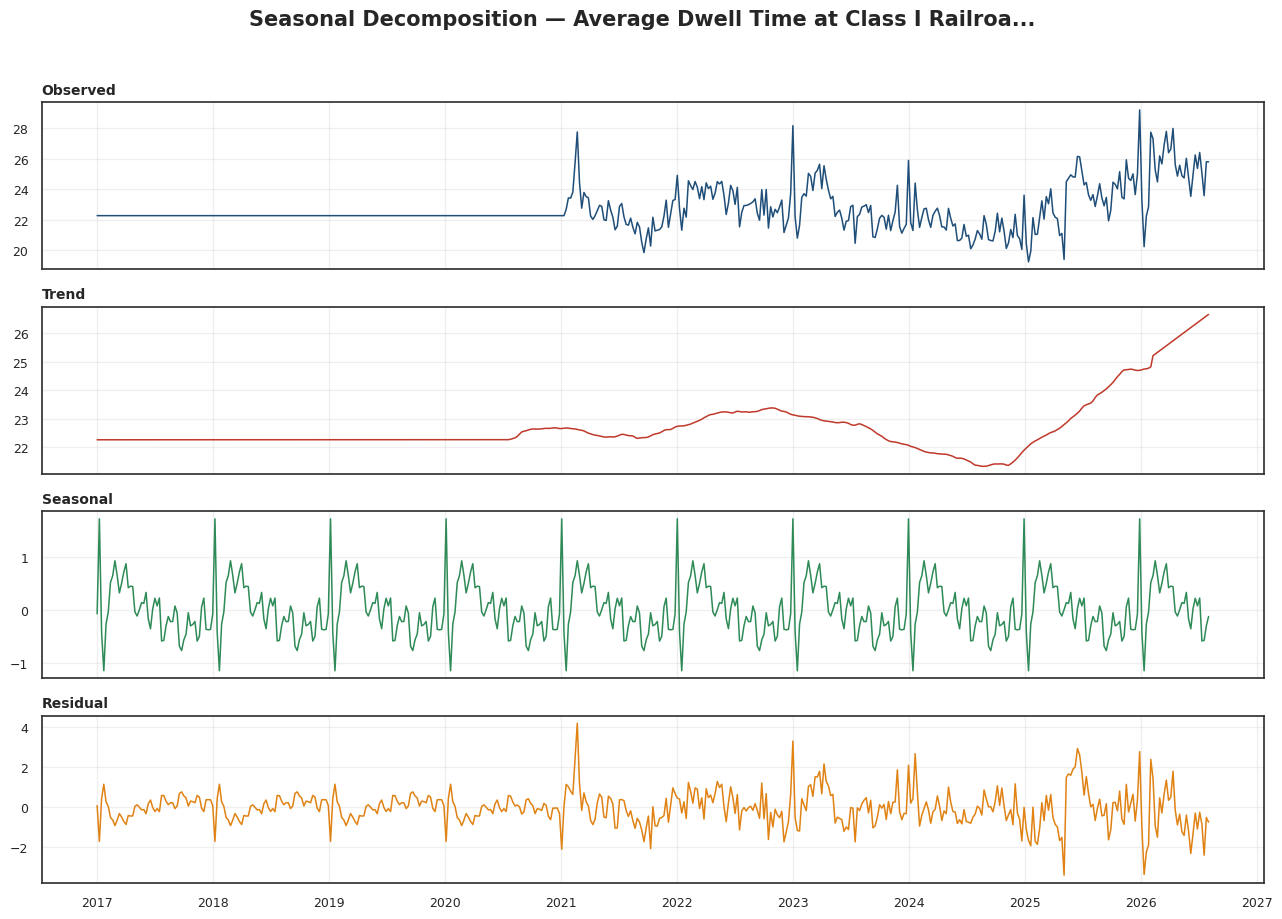

In [22]:
decomp = seasonal_decompose(series.dropna(), model='additive', period=52, extrapolate_trend='freq')
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, (title, comp, color) in zip(axes, [('Observed', decomp.observed, COLOR_MAIN),
                                            ('Trend', decomp.trend, COLOR_ACCENT),
                                            ('Seasonal', decomp.seasonal, COLOR_OK),
                                            ('Residual', decomp.resid, COLOR_WARN)]):
    ax.plot(comp.index, comp, color=color, linewidth=1.1); ax.set_title(title, loc='left', fontsize=10)
fig.suptitle(f'Seasonal Decomposition — {PRIMARY_COL}', y=1.02)
plt.tight_layout(); plt.show()

ADF Statistic: -1.9951
p-value: 0.2887
Non-stationary (differencing may be required)


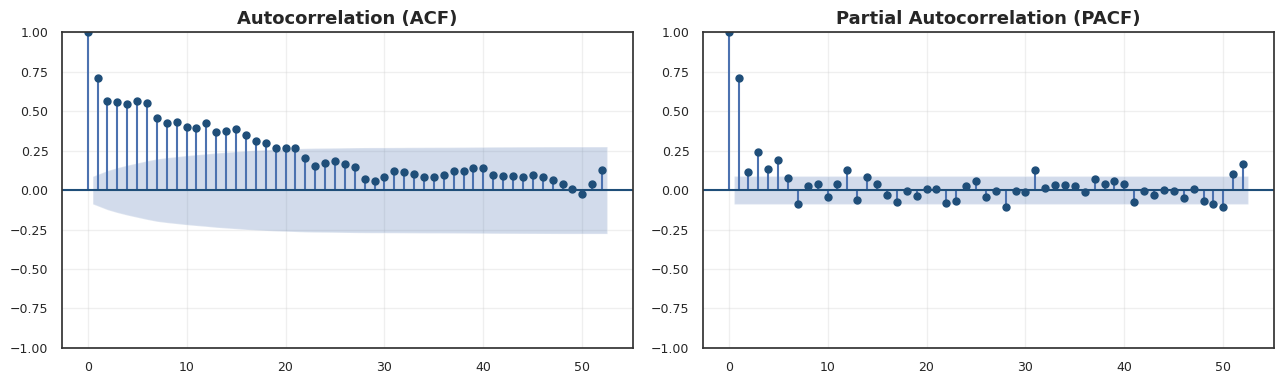

In [23]:
adf_result = adfuller(series.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Stationary" if adf_result[1] < 0.05 else "Non-stationary (differencing may be required)")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series.dropna(), ax=axes[0], lags=52, color=COLOR_MAIN)
plot_pacf(series.dropna(), ax=axes[1], lags=52, color=COLOR_MAIN, method='ywm')
axes[0].set_title('Autocorrelation (ACF)'); axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout(); plt.show()

### 5.8 Dashboard — Rolling Mean + Rolling Volatility

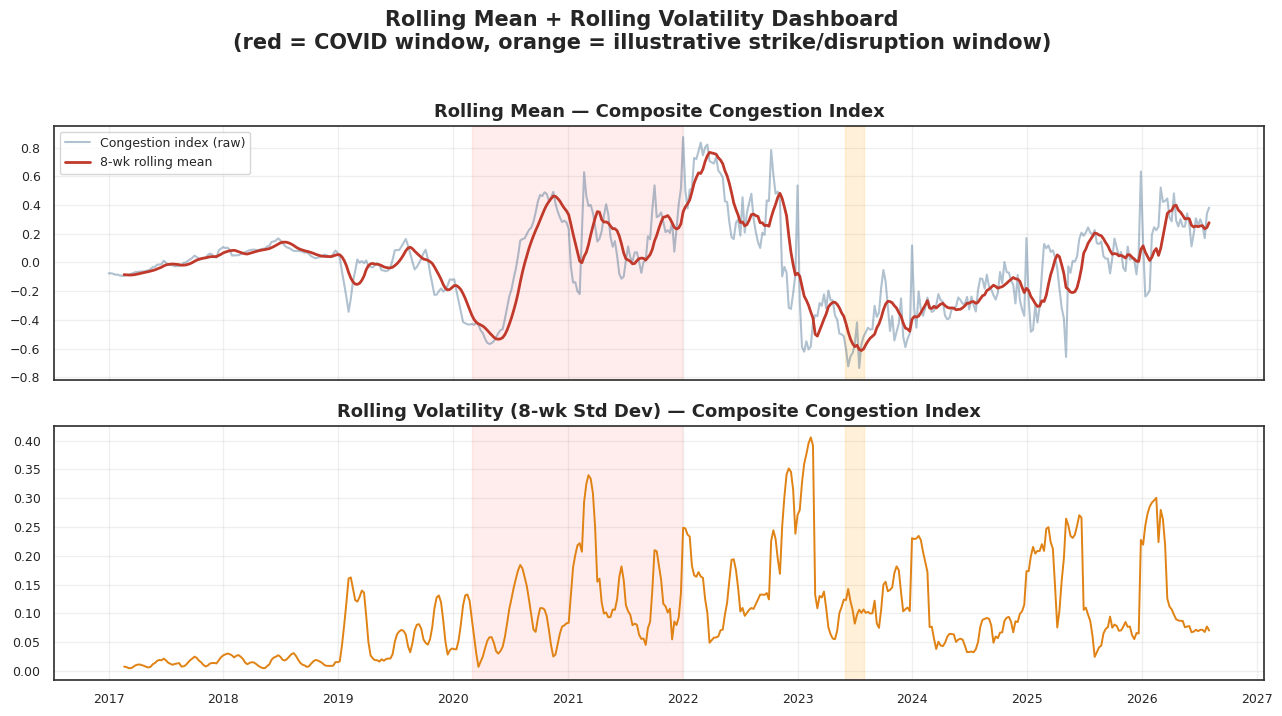

In [24]:
ci_series = wide_ci["congestion_index"]
roll_mean_ci = ci_series.rolling(8).mean()
roll_std_ci = ci_series.rolling(8).std()
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(ci_series.index, ci_series, color=COLOR_MAIN, alpha=0.35, label='Congestion index (raw)')
axes[0].plot(roll_mean_ci.index, roll_mean_ci, color=COLOR_ACCENT, linewidth=2, label='8-wk rolling mean')
axes[0].axvspan(COVID_START, COVID_END, color="red", alpha=0.07)
axes[0].axvspan(STRIKE_START, STRIKE_END, color="orange", alpha=0.15)
axes[0].set_title("Rolling Mean — Composite Congestion Index"); axes[0].legend()
axes[1].plot(roll_std_ci.index, roll_std_ci, color=COLOR_WARN, linewidth=1.4)
axes[1].axvspan(COVID_START, COVID_END, color="red", alpha=0.07)
axes[1].axvspan(STRIKE_START, STRIKE_END, color="orange", alpha=0.15)
axes[1].set_title("Rolling Volatility (8-wk Std Dev) — Composite Congestion Index")
fig.suptitle("Rolling Mean + Rolling Volatility Dashboard\n(red = COVID window, orange = illustrative strike/disruption window)", y=1.02)
plt.tight_layout(); plt.show()

## 6. Feature Engineering
Builds lag/rolling features and forecast targets for the primary series, plus a binary
**delay-risk classification target** derived from the composite freight risk score, and calendar
and shock-event flags.

In [25]:
features = wide_ci.copy()

In [26]:
features["wow_change"] = features[PRIMARY_COL].pct_change()
for lag in [1, 2, 4]:
    features[f"lag_{lag}"] = features[PRIMARY_COL].shift(lag)
features["roll_mean_4"] = features[PRIMARY_COL].rolling(4).mean()
features["roll_std_4"] = features[PRIMARY_COL].rolling(4).std()

In [27]:
features["covid_flag"] = features.index.to_series().between(COVID_START, COVID_END).astype(int)
features["strike_flag"] = features.index.to_series().between(STRIKE_START, STRIKE_END).astype(int)

In [28]:
features["month"] = features.index.month
features["weekofyear"] = features.index.isocalendar().week.astype(int)

In [29]:
features["target_next"] = features[PRIMARY_COL].shift(-1)

In [30]:
risk_threshold = features["freight_risk_score"].quantile(0.75)
features["target_clf"] = (features["freight_risk_score"].shift(-1) > risk_threshold).astype(int)
print(f"High-risk threshold (75th pct of freight_risk_score): {risk_threshold:.2f}")
features_model = features.dropna().copy()
print("Feature matrix shape (after dropping warm-up/lag rows):", features_model.shape)
features_model.head()

High-risk threshold (75th pct of freight_risk_score): 56.13
Feature matrix shape (after dropping warm-up/lag rows): (496, 24)


INDICATOR,Average Dwell Time at Class I Railroa...,Average Terminal Dwell Time in Hours ...,Average Train Speed in MPH by Railroad,Downbound Grain Barge Rates,Empty Export Containers at Select U.S...,Loaded Export Containers at Select U....,Loaded Import Containers at Select U....,Number of Containerships Awaiting Ber...,Rail Cars Online,Truck Spot Rates in $ per Mile by Tru...,...,lag_2,lag_4,roll_mean_4,roll_std_4,covid_flag,strike_flag,month,weekofyear,target_next,target_clf
DATE,,,,,,,,,,,,,,,,,,,,,
2017-01-29,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.590000,...,22.258571,22.258571,22.258571,0.0,0,0,1,4,22.258571,0
2017-02-05,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.571667,...,22.258571,22.258571,22.258571,0.0,0,0,2,5,22.258571,0
2017-02-12,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.566333,...,22.258571,22.258571,22.258571,0.0,0,0,2,6,22.258571,0
2017-02-19,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.560667,...,22.258571,22.258571,22.258571,0.0,0,0,2,7,22.258571,0
2017-02-26,22.258571,24.444286,25.818571,14.306,107177.777778,98944.744444,199375.4,32.0,138791.265306,1.579000,...,22.258571,22.258571,22.258571,0.0,0,0,2,8,22.258571,0


## 7. Anomaly Detection

### 7.1 Dashboard — Isolation Forest + CUSUM Change Detection

In [31]:
iso_features = list(wide.columns)
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE)
anomaly_pred = iso.fit_predict(features_model[iso_features])
features_model["is_anomaly"] = (anomaly_pred == -1).astype(int)

In [32]:
ci = features_model["congestion_index"]
mean_ci = ci.mean()
cusum_pos, cusum_neg = [0.0], [0.0]
for x in ci.diff().fillna(0):
    cusum_pos.append(max(0, cusum_pos[-1] + x))
    cusum_neg.append(min(0, cusum_neg[-1] + x))
cusum_pos, cusum_neg = pd.Series(cusum_pos[1:], index=ci.index), pd.Series(cusum_neg[1:], index=ci.index)
cusum_threshold = 3 * ci.std()
structural_break = (cusum_pos.abs() > cusum_threshold) | (cusum_neg.abs() > cusum_threshold)

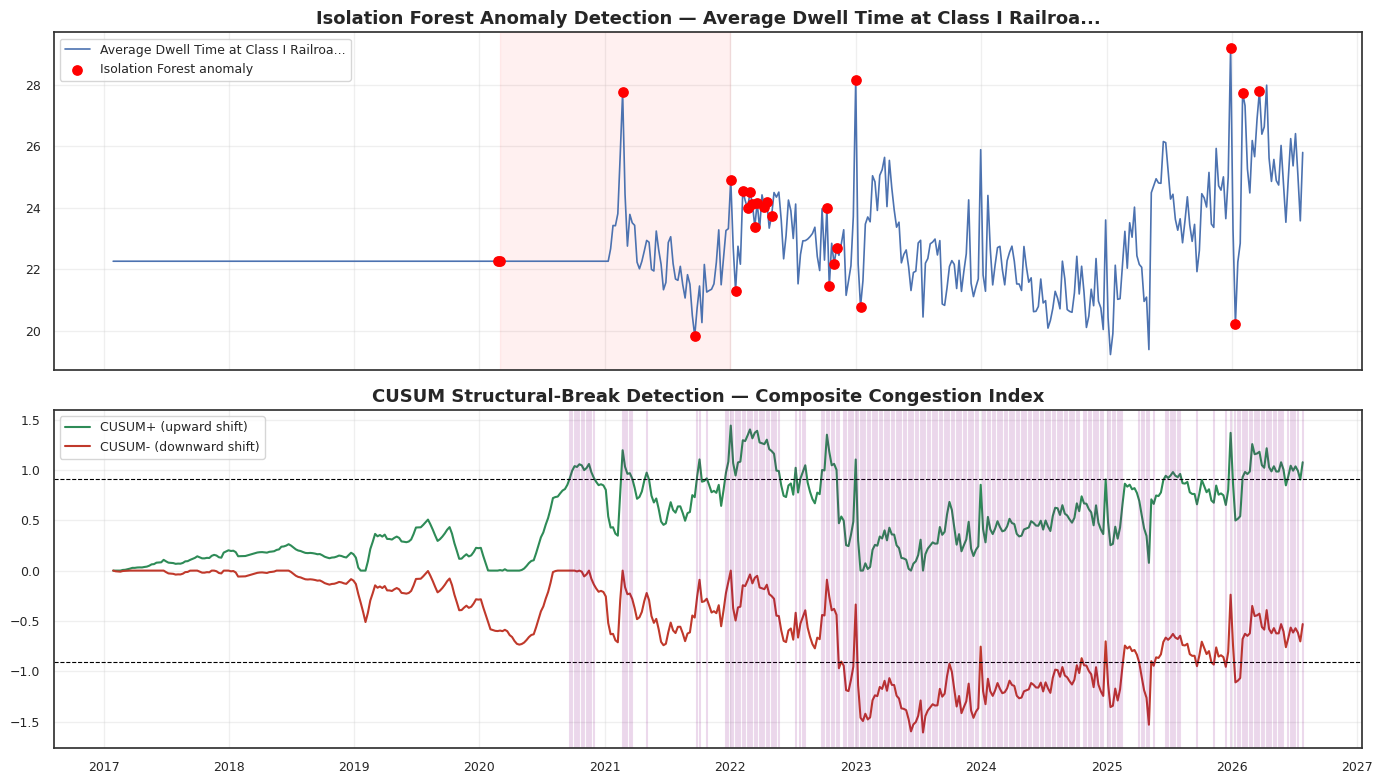

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(features_model.index, features_model[PRIMARY_COL], color="#4C72B0", linewidth=1.2, label=PRIMARY_COL)
anoms = features_model[features_model["is_anomaly"] == 1]
axes[0].scatter(anoms.index, anoms[PRIMARY_COL], color="red", s=45, zorder=5, label="Isolation Forest anomaly")
axes[0].axvspan(COVID_START, COVID_END, color="red", alpha=0.06)
axes[0].set_title(f"Isolation Forest Anomaly Detection — {PRIMARY_COL}")
axes[0].legend()
axes[1].plot(cusum_pos.index, cusum_pos, color=COLOR_OK, label="CUSUM+ (upward shift)")
axes[1].plot(cusum_neg.index, cusum_neg, color=COLOR_ACCENT, label="CUSUM- (downward shift)")
axes[1].axhline(cusum_threshold, color="black", linestyle="--", linewidth=0.8)
axes[1].axhline(-cusum_threshold, color="black", linestyle="--", linewidth=0.8)
breaks = features_model.index[structural_break]
for b in breaks:
    axes[1].axvline(b, color="purple", alpha=0.15)
axes[1].set_title("CUSUM Structural-Break Detection — Composite Congestion Index")
axes[1].legend()
plt.tight_layout(); plt.show()

In [34]:
print(f"Isolation Forest flagged {features_model['is_anomaly'].sum()} of {len(features_model)} "
      f"weeks ({features_model['is_anomaly'].mean():.1%}) as anomalous.")
print(f"CUSUM flagged {structural_break.sum()} weeks as structural-break candidates.")

Isolation Forest flagged 25 of 496 weeks (5.0%) as anomalous.
CUSUM flagged 213 weeks as structural-break candidates.


## 8. Train / Test Split (Time-Aware, Chronological)

In [35]:
feature_cols = [c for c in features_model.columns
                if c not in ["target_next", "target_clf", "is_anomaly"]]
split_idx = int(len(features_model) * 0.8)
train_df = features_model.iloc[:split_idx]
test_df = features_model.iloc[split_idx:]

In [36]:
X_train, y_train = train_df[feature_cols], train_df["target_next"]
X_test, y_test = test_df[feature_cols], test_df["target_next"]
y_train_clf, y_test_clf = train_df["target_clf"], test_df["target_clf"]

In [37]:
print(f"Train: {train_df.index.min().date()} -> {train_df.index.max().date()} ({len(train_df)} weeks)")
print(f"Test : {test_df.index.min().date()} -> {test_df.index.max().date()} ({len(test_df)} weeks)")
print(f"Test-set positive (high-risk) rate: {y_test_clf.mean():.1%}")
results = {}
clf_results = {}

Train: 2017-01-29 -> 2024-08-25 (396 weeks)
Test : 2024-09-01 -> 2026-07-26 (100 weeks)
Test-set positive (high-risk) rate: 35.0%


## 9. Baseline Classification Models

### 9.1 Logistic Regression — Interpretable Baseline Classifier
A linear baseline for the binary delay-risk classification target. Coefficients give a directly
interpretable sense of which engineered features push the high-risk probability up or down.

In [38]:
log_reg = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=2000,
    class_weight='balanced', random_state=RANDOM_STATE
)
log_reg.fit(X_train, y_train_clf)
pred_logreg = log_reg.predict(X_test)
proba_logreg = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression — parameters & train process")
print(f"  penalty={log_reg.penalty}, C={log_reg.C}, solver={log_reg.solver}, "
      f"max_iter={log_reg.max_iter}, class_weight={log_reg.class_weight}")
print(f"  Converged in {log_reg.n_iter_[0]} iterations on {X_train.shape[0]} training weeks "
      f"x {X_train.shape[1]} features")

coef_tbl = pd.Series(log_reg.coef_[0], index=feature_cols).sort_values(key=np.abs, ascending=False).head(10)
print("\nTop 10 features by |coefficient| (log-odds scale):")
print(coef_tbl)

Logistic Regression — parameters & train process
  penalty=l2, C=1.0, solver=lbfgs, max_iter=2000, class_weight=balanced
  Converged in 2000 iterations on 396 training weeks x 22 features

Top 10 features by |coefficient| (log-odds scale):
month                                       1.018707
Average Terminal Dwell Time in Hours ...   -0.592935
Average Train Speed in MPH by Railroad     -0.447622
covid_flag                                  0.403766
lag_4                                       0.374744
freight_risk_score                          0.361880
lag_2                                       0.273275
weekofyear                                 -0.217446
roll_mean_4                                 0.178897
roll_std_4                                  0.136541
dtype: float64


### 9.2 Random Forest Classifier — Ensemble Baseline

In [39]:
rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=6, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train, y_train_clf)
pred_rf_clf = rf_clf.predict(X_test)
proba_rf_clf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest Classifier — parameters & train process")
print(f"  n_estimators={rf_clf.n_estimators}, max_depth={rf_clf.max_depth}, "
      f"class_weight={rf_clf.class_weight}, random_state={rf_clf.random_state}")
print(f"  Trained on {X_train.shape[0]} weeks x {X_train.shape[1]} features "
      f"({int(y_train_clf.sum())} high-risk / {int((1 - y_train_clf).sum())} low-risk weeks)")

Random Forest Classifier — parameters & train process
  n_estimators=400, max_depth=6, class_weight=balanced, random_state=42
  Trained on 396 weeks x 22 features (90 high-risk / 306 low-risk weeks)


## 10. Advanced Classification Models

### 10.1 LSTM — Sequence Classifier for Temporal Delay-Risk Prediction
Uses the same 8-week lookback windows as an ordinary sequence model, but the target is the
binary `target_clf` label rather than a continuous next-step value, so the network is trained
as a binary classifier (sigmoid output head, binary cross-entropy loss, class-weighted for the
imbalance between high-risk and low-risk weeks).

LSTM — architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,233 (137.63 KB)

 Trainable params: 35,233 (137.63 KB)

 Non-trainable params: 0 (0.00 B)


LSTM — train process: lookback=8 weeks, optimizer=adam, loss=binary_crossentropy, batch_size=16, max_epochs=100, early_stopping(monitor='val_loss', patience=8), class_weight={0: np.float64(0.6510067114093959), 1: np.float64(2.1555555555555554)}
Stopped after 14 epochs (best val_loss=0.2214)


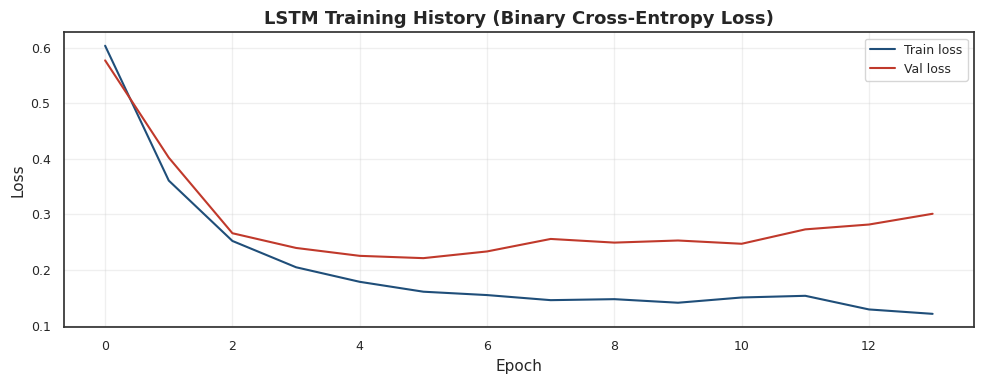

In [40]:
LOOKBACK = 8

def make_sequences(data, target, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(target[i])
    return np.array(X), np.array(y)

scaler_x = StandardScaler().fit(train_df[feature_cols])
X_all_scaled = scaler_x.transform(features_model[feature_cols])
y_all_clf = features_model["target_clf"].values

X_seq, y_seq_clf = make_sequences(X_all_scaled, y_all_clf, LOOKBACK)
seq_split = split_idx - LOOKBACK
X_seq_train, X_seq_test = X_seq[:seq_split], X_seq[seq_split:]
y_seq_train_clf, y_seq_test_clf = y_seq_clf[:seq_split], y_seq_clf[seq_split:]
seq_test_index = features_model.index[LOOKBACK:][seq_split:]

pos = y_seq_train_clf.sum()
neg = len(y_seq_train_clf) - pos
class_weight_seq = {0: len(y_seq_train_clf) / (2 * neg), 1: len(y_seq_train_clf) / (2 * max(pos, 1))}

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("LSTM — architecture")
lstm_model.summary()
print(f"\nLSTM — train process: lookback={LOOKBACK} weeks, optimizer=adam, "
      f"loss=binary_crossentropy, batch_size=16, max_epochs=100, "
      f"early_stopping(monitor='val_loss', patience=8), class_weight={class_weight_seq}")

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = lstm_model.fit(X_seq_train, y_seq_train_clf, validation_split=0.15,
                          epochs=100, batch_size=16, callbacks=[es],
                          class_weight=class_weight_seq, verbose=0)
print(f"Stopped after {len(history.history['loss'])} epochs "
      f"(best val_loss={min(history.history['val_loss']):.4f})")

proba_lstm_clf = lstm_model.predict(X_seq_test, verbose=0).flatten()
pred_lstm_clf = (proba_lstm_clf >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train loss', color=COLOR_MAIN)
ax.plot(history.history['val_loss'], label='Val loss', color=COLOR_ACCENT)
ax.set_title('LSTM Training History (Binary Cross-Entropy Loss)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout(); plt.show()

### 10.2 Transformer — Attention-Based Sequence Classifier
Same multi-head self-attention block as a standard time-series Transformer encoder, now with a
sigmoid output head trained with binary cross-entropy loss for the delay-risk classification
target (same lookback windows and class weighting as the LSTM above).

Transformer — architecture


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 22)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 22)     │      5,846 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 22)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 22)     │         44 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8, 64)     │      1,472 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8, 22)     │      1,430 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 22)     │          0 │ dense_3[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 22)     │         44 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 22)     │      5,846 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 22)     │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 22)     │         44 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8, 64)     │      1,472 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8, 22)     │      1,430 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 8, 22)     │          0 │ dense_5[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 22)     │         44 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 22)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        736 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0] 

 Total params: 18,441 (72.04 KB)

 Trainable params: 18,441 (72.04 KB)

 Non-trainable params: 0 (0.00 B)


Transformer — train process: 2 stacked transformer blocks (head_size=32, num_heads=2, ff_dim=64, dropout=0.15), optimizer=adam, loss=binary_crossentropy, batch_size=16, max_epochs=100, early_stopping(monitor='val_loss', patience=8), class_weight={0: np.float64(0.6510067114093959), 1: np.float64(2.1555555555555554)}
Stopped after 15 epochs (best val_loss=0.3218)


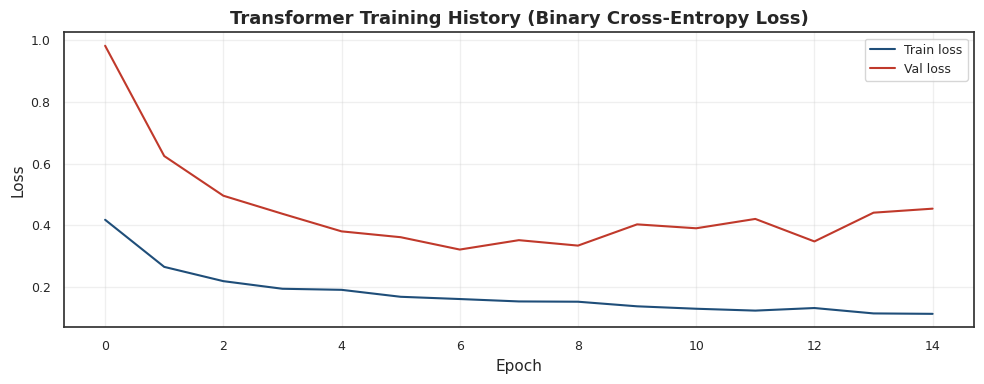

In [41]:
def transformer_block(inputs, head_size=32, num_heads=2, ff_dim=64, dropout=0.15):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dense(inputs.shape[-1])(ff)
    return LayerNormalization(epsilon=1e-6)(ff + x)

inp = Input(shape=(LOOKBACK, X_seq.shape[2]))
x = transformer_block(inp)
x = transformer_block(x)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
out = Dense(1, activation='sigmoid')(x)
transformer_model = Model(inp, out)
transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Transformer — architecture")
transformer_model.summary()
print(f"\nTransformer — train process: 2 stacked transformer blocks "
      f"(head_size=32, num_heads=2, ff_dim=64, dropout=0.15), optimizer=adam, "
      f"loss=binary_crossentropy, batch_size=16, max_epochs=100, "
      f"early_stopping(monitor='val_loss', patience=8), class_weight={class_weight_seq}")

es2 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
t_history = transformer_model.fit(X_seq_train, y_seq_train_clf, validation_split=0.15,
                                   epochs=100, batch_size=16, callbacks=[es2],
                                   class_weight=class_weight_seq, verbose=0)
print(f"Stopped after {len(t_history.history['loss'])} epochs "
      f"(best val_loss={min(t_history.history['val_loss']):.4f})")

proba_transformer_clf = transformer_model.predict(X_seq_test, verbose=0).flatten()
pred_transformer_clf = (proba_transformer_clf >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_history.history['loss'], label='Train loss', color=COLOR_MAIN)
ax.plot(t_history.history['val_loss'], label='Val loss', color=COLOR_ACCENT)
ax.set_title('Transformer Training History (Binary Cross-Entropy Loss)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout(); plt.show()

### 10.3 XGBoost Classifier with SHAP Explainability

In [42]:
pos_weight = (y_train_clf == 0).sum() / max((y_train_clf == 1).sum(), 1)
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
    random_state=RANDOM_STATE, eval_metric='logloss'
)
xgb_clf.fit(X_train, y_train_clf)
pred_xgb_clf = xgb_clf.predict(X_test)
proba_xgb_clf = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost Classifier — parameters & train process")
print(f"  n_estimators={xgb_clf.n_estimators}, max_depth={xgb_clf.max_depth}, "
      f"learning_rate={xgb_clf.learning_rate}, subsample={xgb_clf.subsample}, "
      f"colsample_bytree={xgb_clf.colsample_bytree}, scale_pos_weight={pos_weight:.2f}")
print(f"  Trained on {X_train.shape[0]} weeks x {X_train.shape[1]} features")

XGBoost Classifier — parameters & train process
  n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=3.40
  Trained on 396 weeks x 22 features


### 10.4 Dashboard — Feature Importance (Random Forest & XGBoost Classifiers)

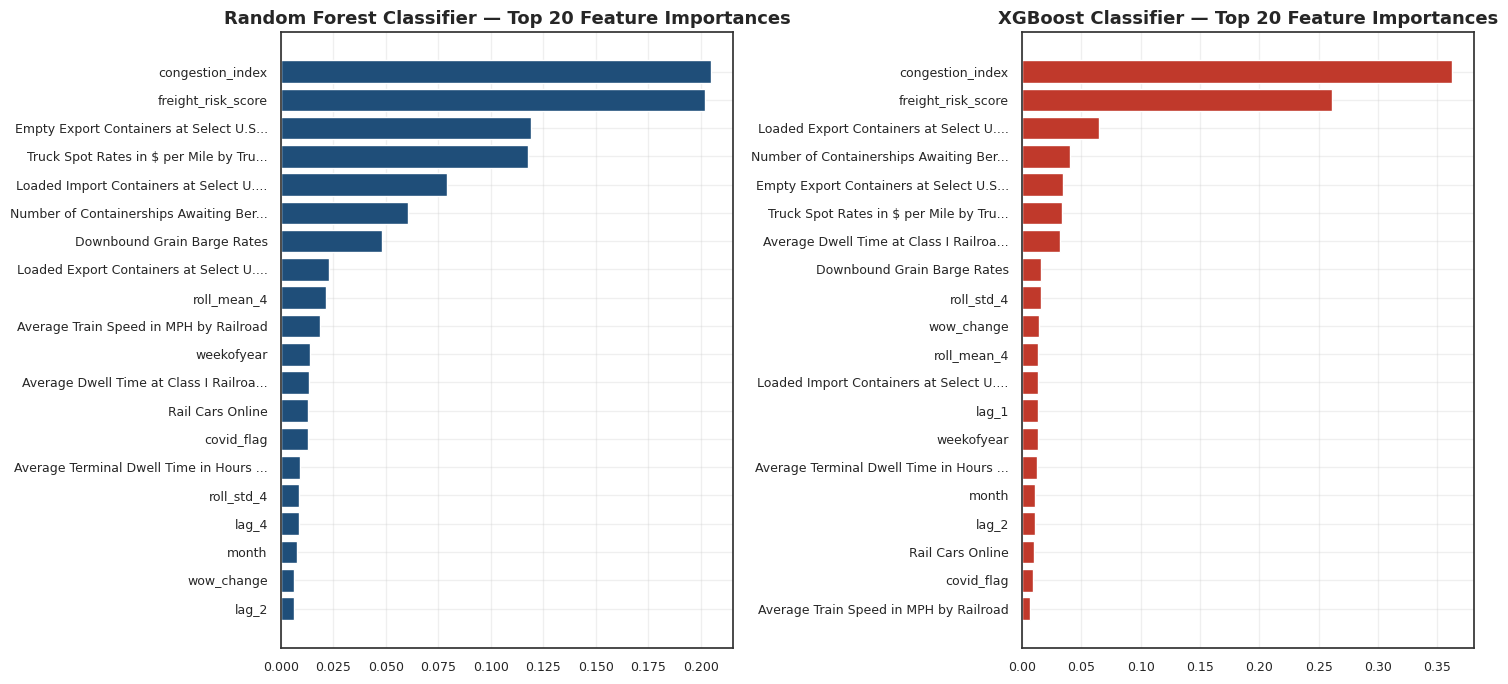

In [43]:
imp_rf = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
imp_xgb = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].barh(imp_rf.index[::-1], imp_rf.values[::-1], color=COLOR_MAIN)
axes[0].set_title("Random Forest Classifier — Top 20 Feature Importances")
axes[1].barh(imp_xgb.index[::-1], imp_xgb.values[::-1], color=COLOR_ACCENT)
axes[1].set_title("XGBoost Classifier — Top 20 Feature Importances")
plt.tight_layout(); plt.show()

### 10.5 SHAP Explainability (Summary, Bar, Waterfall, Dependence) — XGBoost Classifier

In [44]:
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_test)

def shorten_feature_name(name, max_len=25):
    return name if len(name) <= max_len else name[:max_len-3] + '...'

X_test_short_names = X_test.rename(columns={col: shorten_feature_name(col) for col in X_test.columns})

In [45]:
def shorten_feature(name, max_len=35):
    return name if len(name) <= max_len else name[:max_len] + "..."

X_test_short = X_test.rename(
    columns={c: shorten_feature(c) for c in X_test.columns}
)

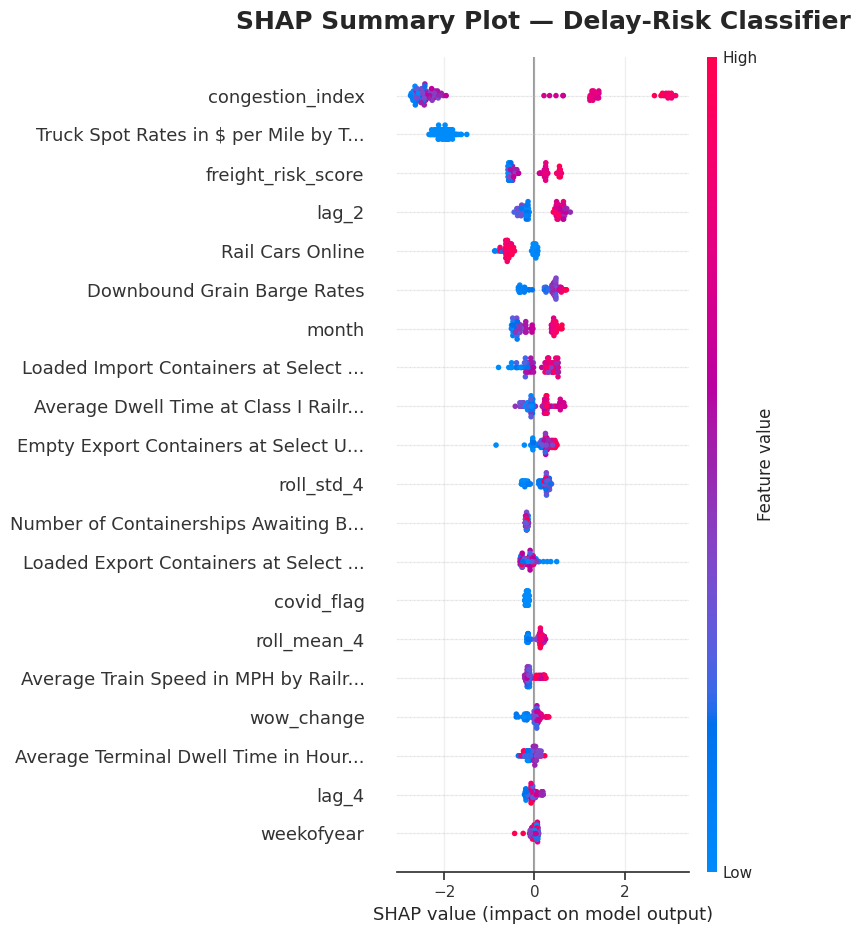

In [46]:
plt.figure(figsize=(12,10))
shap.summary_plot(
    shap_values.values,
    X_test_short,
    show=False
)

plt.title(
    "SHAP Summary Plot — Delay-Risk Classifier",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

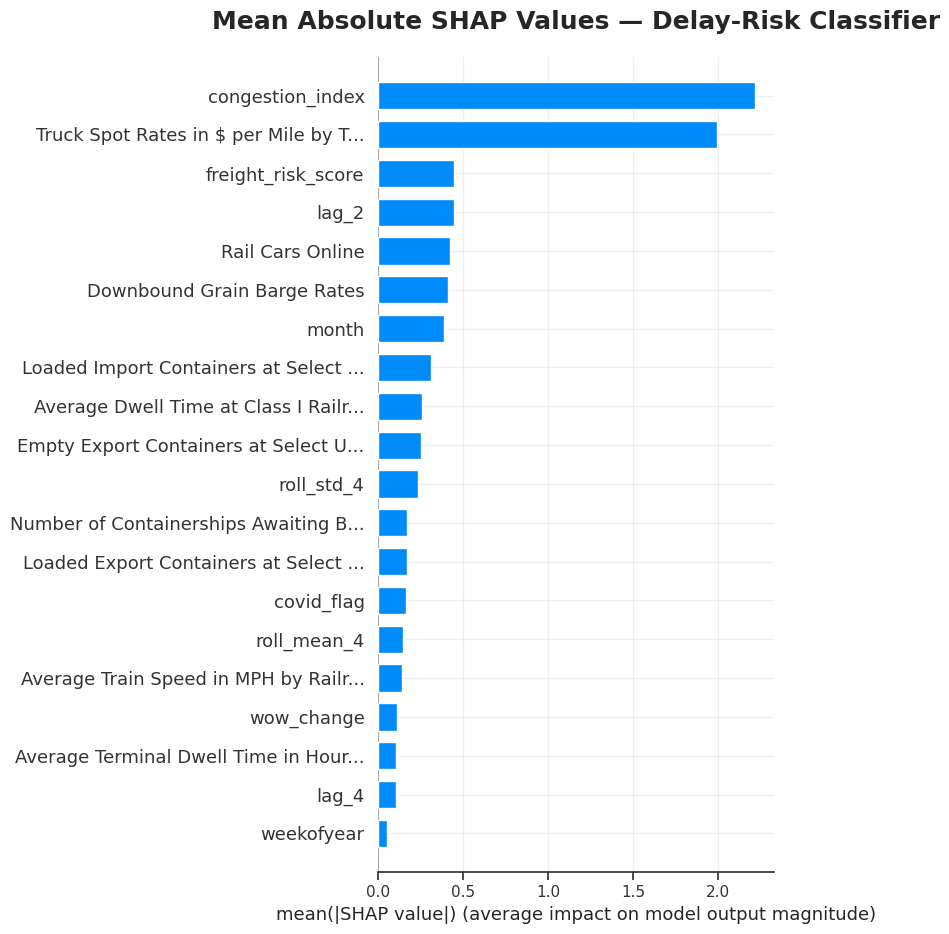

In [47]:
plt.figure(figsize=(12,8))
shap.summary_plot(
    shap_values.values,
    X_test_short,
    plot_type="bar",
    show=False
)
plt.title(
    "Mean Absolute SHAP Values — Delay-Risk Classifier",
    fontsize=18,
    fontweight="bold",
    pad=20
)
plt.tight_layout()
plt.show()

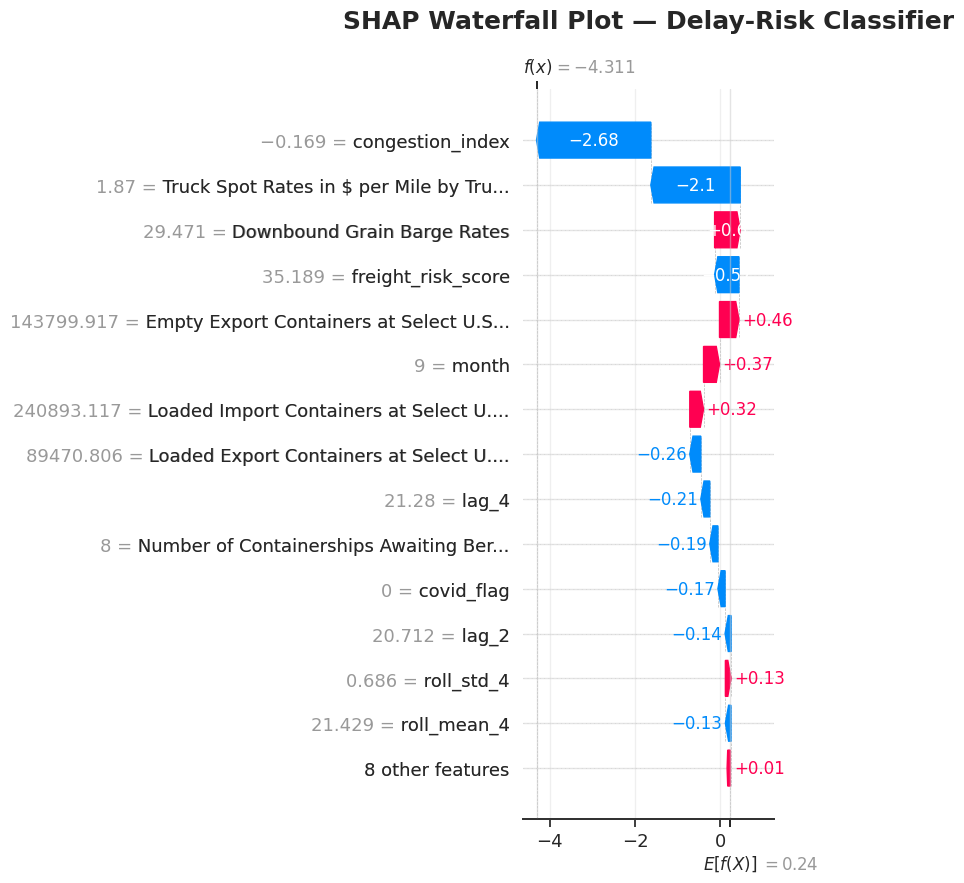

In [48]:
plt.figure(figsize=(12,8))
shap.plots.waterfall(
    shap_values[0],
    max_display=15,
    show=False
)
plt.title(
    "SHAP Waterfall Plot — Delay-Risk Classifier",
    fontsize=18,
    fontweight="bold",
    pad=20
)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

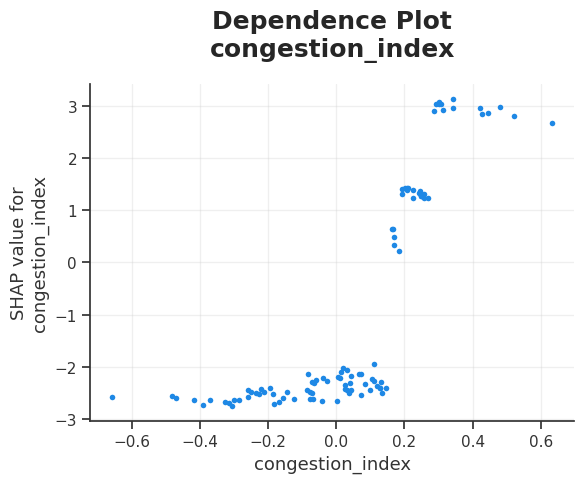

In [49]:
plt.figure(figsize=(12,8))
top_feature = imp_xgb.index[0]
shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_test_short,
    interaction_index=None,
    show=False
)
plt.title(
    f"Dependence Plot\n{shorten_feature(top_feature)}",
    fontsize=18,
    fontweight="bold",
    pad=20
)
plt.tight_layout()
plt.show()

## 11. Model Evaluation & Comparison (Classification)

### 11.1 Classification Metrics — Binary Delay-Risk Prediction

In [50]:
def eval_classification(y_true, y_pred, y_proba, name):
    auc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    clf_results[name] = {"AUC-ROC": auc, "F1-score": f1}
    print(f"{name:22s} | AUC-ROC={auc:.3f}  F1={f1:.3f}")
    return auc, f1

clf_results = {}
eval_classification(y_test_clf, pred_logreg, proba_logreg, "Logistic Regression")
eval_classification(y_test_clf, pred_rf_clf, proba_rf_clf, "Random Forest")
eval_classification(y_test_clf, pred_xgb_clf, proba_xgb_clf, "XGBoost")
eval_classification(y_seq_test_clf, pred_lstm_clf, proba_lstm_clf, "LSTM")
eval_classification(y_seq_test_clf, pred_transformer_clf, proba_transformer_clf, "Transformer")

clf_results_df = pd.DataFrame(clf_results).T.round(3).sort_values("AUC-ROC", ascending=False)
clf_results_df

Logistic Regression    | AUC-ROC=0.938  F1=0.687
Random Forest          | AUC-ROC=0.914  F1=0.458
XGBoost                | AUC-ROC=0.918  F1=0.754
LSTM                   | AUC-ROC=0.473  F1=0.400
Transformer            | AUC-ROC=0.241  F1=0.029


,AUC-ROC,F1-score
Logistic Regression,0.938,0.687
XGBoost,0.918,0.754
Random Forest,0.914,0.458
LSTM,0.473,0.400
Transformer,0.241,0.029


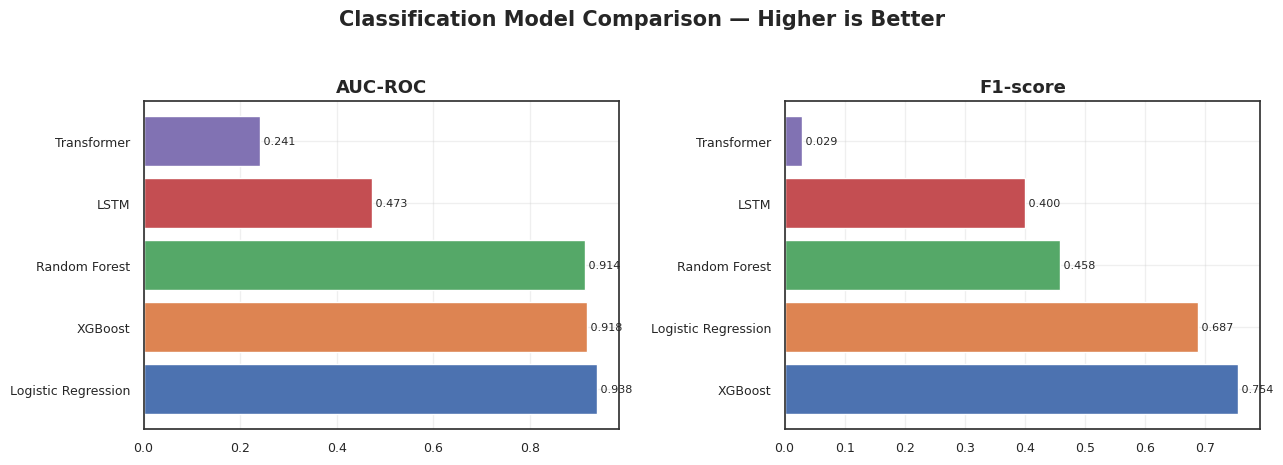

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = sns.color_palette('deep', len(clf_results_df))
for ax, metric in zip(axes, ["AUC-ROC", "F1-score"]):
    sorted_df = clf_results_df.sort_values(metric, ascending=False)
    ax.barh(sorted_df.index, sorted_df[metric], color=colors)
    ax.set_title(metric)
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
fig.suptitle('Classification Model Comparison — Higher is Better', y=1.03)
plt.tight_layout(); plt.show()

### 11.2 ROC Curves & Confusion Matrices — All Classifiers

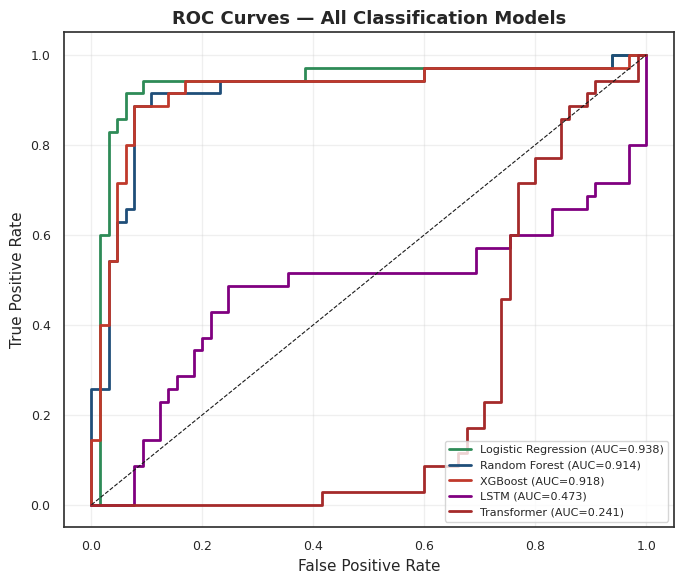

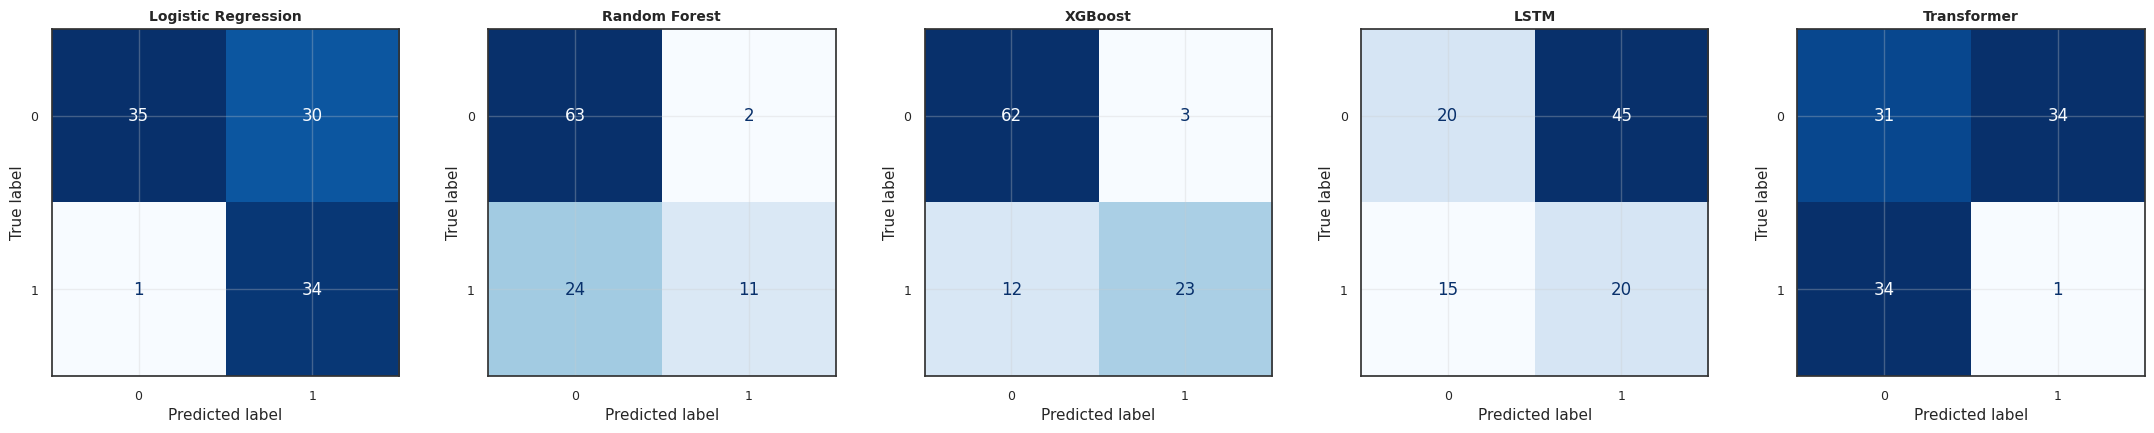

In [52]:
model_preds = {
    "Logistic Regression": (y_test_clf, pred_logreg, proba_logreg),
    "Random Forest": (y_test_clf, pred_rf_clf, proba_rf_clf),
    "XGBoost": (y_test_clf, pred_xgb_clf, proba_xgb_clf),
    "LSTM": (y_seq_test_clf, pred_lstm_clf, proba_lstm_clf),
    "Transformer": (y_seq_test_clf, pred_transformer_clf, proba_transformer_clf),
}
model_colors = {
    "Logistic Regression": COLOR_OK, "Random Forest": COLOR_MAIN,
    "XGBoost": COLOR_ACCENT, "LSTM": "purple", "Transformer": "brown",
}

fig, ax = plt.subplots(figsize=(7, 6))
for name, (yt, yp, proba) in model_preds.items():
    fpr, tpr, _ = roc_curve(yt, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(yt, proba):.3f})',
            color=model_colors[name], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves — All Classification Models')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (name, (yt, yp, proba)) in zip(axes, model_preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(yt, yp)).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

In [53]:
for name, (yt, yp, proba) in model_preds.items():
    print(f"{name} classification report:\n", classification_report(yt, yp))

Logistic Regression classification report:
               precision    recall  f1-score   support

           0       0.97      0.54      0.69        65
           1       0.53      0.97      0.69        35

    accuracy                           0.69       100
   macro avg       0.75      0.75      0.69       100
weighted avg       0.82      0.69      0.69       100

Random Forest classification report:
               precision    recall  f1-score   support

           0       0.72      0.97      0.83        65
           1       0.85      0.31      0.46        35

    accuracy                           0.74       100
   macro avg       0.79      0.64      0.64       100
weighted avg       0.77      0.74      0.70       100

XGBoost classification report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89        65
           1       0.88      0.66      0.75        35

    accuracy                           0.85       100
   macro avg  

### 11.3 Best Model Performance Diagnostics

Best model by AUC-ROC: Logistic Regression


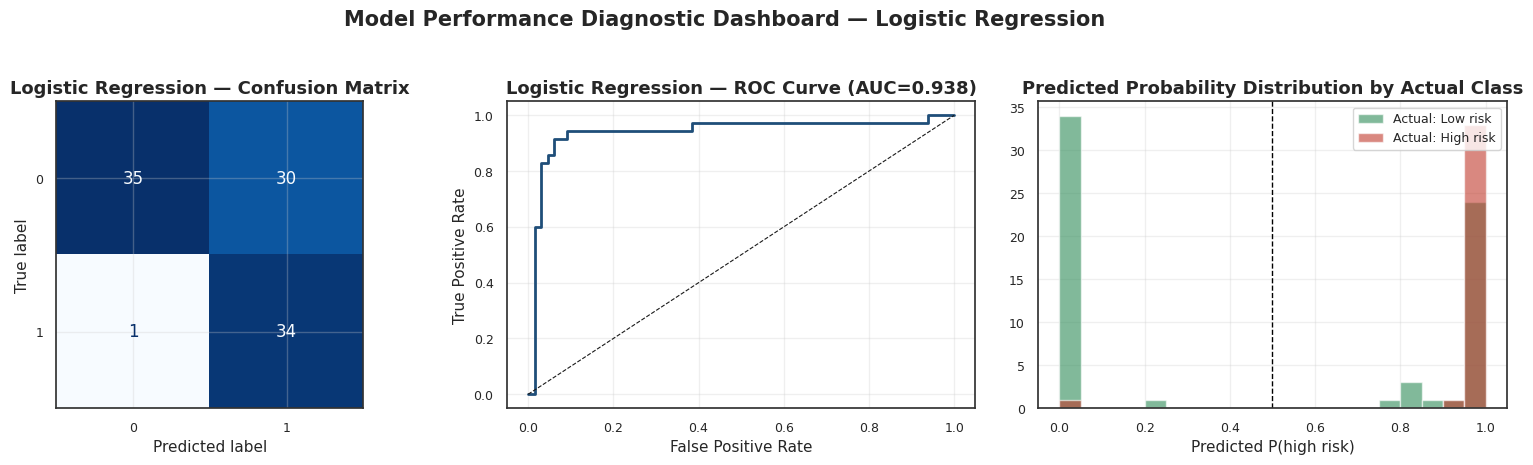

In [54]:
best_model_name = clf_results_df.index[0]
print("Best model by AUC-ROC:", best_model_name)
best_yt, best_yp, best_proba = model_preds[best_model_name]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(best_yt, best_yp)).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_model_name} — Confusion Matrix')

fpr, tpr, _ = roc_curve(best_yt, best_proba)
axes[1].plot(fpr, tpr, color=COLOR_MAIN, linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title(f'{best_model_name} — ROC Curve (AUC={roc_auc_score(best_yt, best_proba):.3f})')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')

axes[2].hist(best_proba[best_yt == 0], bins=20, alpha=0.6, label='Actual: Low risk', color=COLOR_OK)
axes[2].hist(best_proba[best_yt == 1], bins=20, alpha=0.6, label='Actual: High risk', color=COLOR_ACCENT)
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Predicted Probability Distribution by Actual Class')
axes[2].set_xlabel('Predicted P(high risk)'); axes[2].legend()

fig.suptitle(f'Model Performance Diagnostic Dashboard — {best_model_name}', y=1.03)
plt.tight_layout(); plt.show()

## 12. Freight Risk Score Timeline

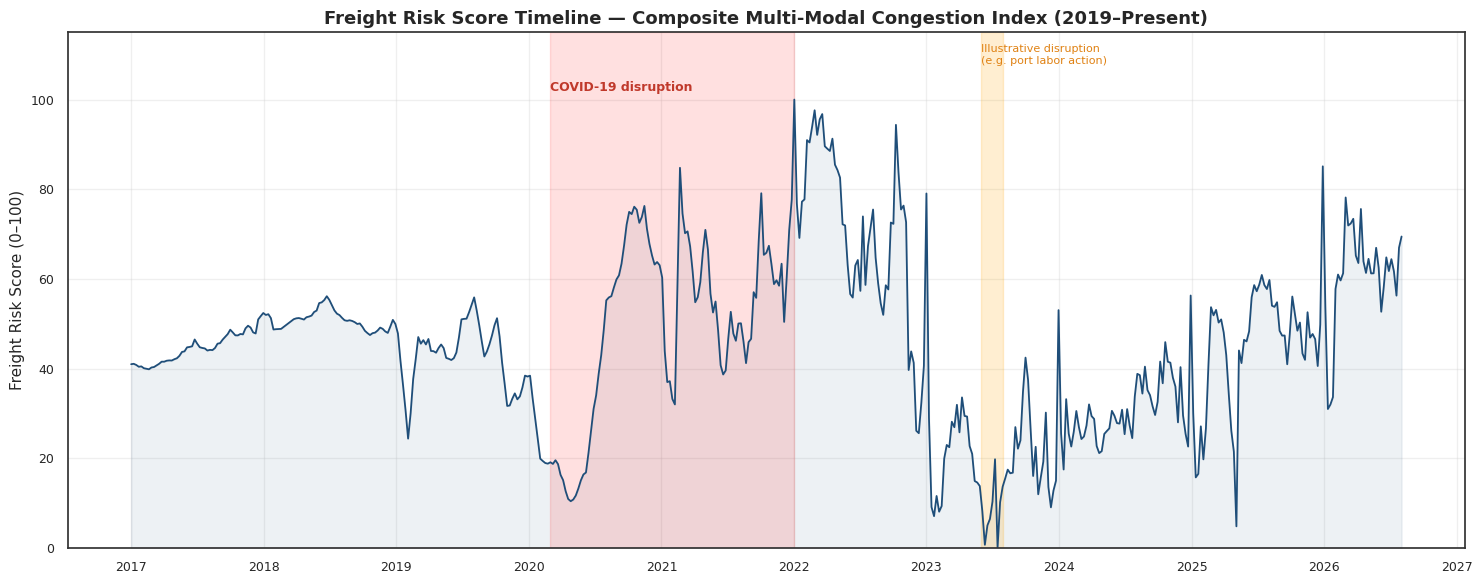

In [55]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wide_ci.index, wide_ci["freight_risk_score"], color=COLOR_MAIN, linewidth=1.3)
ax.fill_between(wide_ci.index, wide_ci["freight_risk_score"], 0, color=COLOR_MAIN, alpha=0.08)
ax.axvspan(COVID_START, COVID_END, color="red", alpha=0.12)
ax.text(COVID_START, 102, "COVID-19 disruption", color=COLOR_ACCENT, fontsize=9, fontweight='bold')
ax.axvspan(STRIKE_START, STRIKE_END, color="orange", alpha=0.18)
ax.text(STRIKE_START, 108, "Illustrative disruption\n(e.g. port labor action)", color=COLOR_WARN, fontsize=8)
ax.axhline(risk_threshold_pct if 'risk_threshold_pct' in dir() else None, color='gray') if False else None
ax.set_ylim(0, 115)
ax.set_ylabel("Freight Risk Score (0–100)")
ax.set_title("Freight Risk Score Timeline — Composite Multi-Modal Congestion Index (2019–Present)")
plt.tight_layout(); plt.show()